/tmp/ipykernel_726368/3619212402.py:65: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_726368/3619212402.py:65: UserWarning: Glyph 21151 (\N{CJK UNIFIED IDEOGRAPH-529F}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_726368/3619212402.py:65: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_726368/3619212402.py:65: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/mori-lab/shimizu/aco-on-spinglass/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/mori-lab/shimizu/aco-on-spinglass/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2

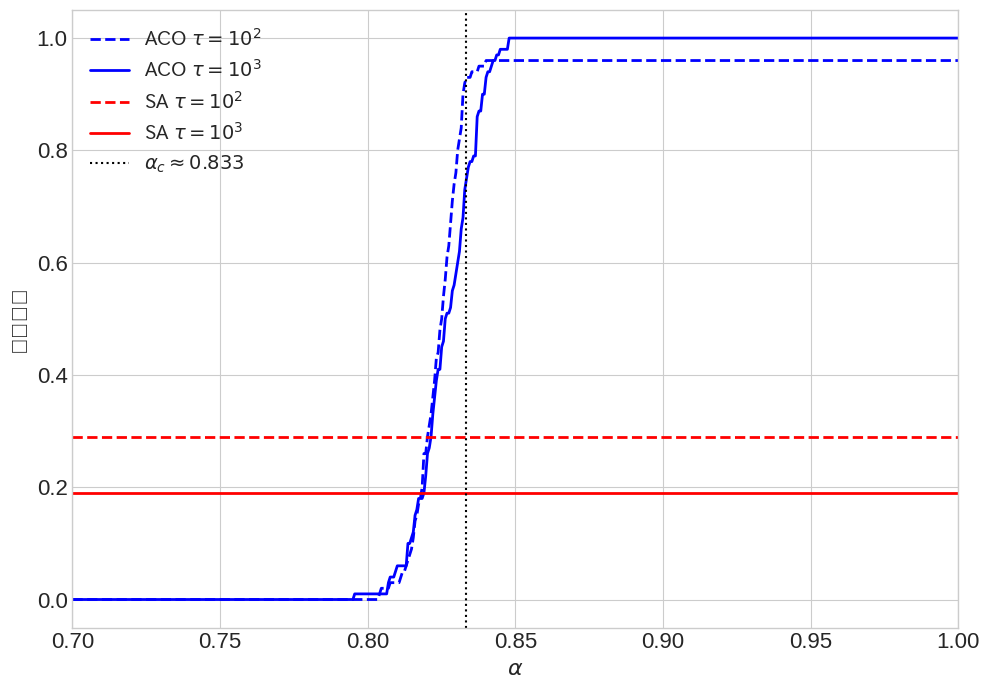

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib_fontja


def plot_success_probability(csv_file):
    # データの読み込み
    try:
        df = pd.read_csv(csv_file)
    except FileNotFoundError:
        print(f"{csv_file} が見つかりません。Juliaコードを実行してください。")
        return

    # プロット設定
    plt.figure(figsize=(10, 7))
    
    # 線のスタイル定義
    # (Method, Tau, Label, Color, LineStyle)
    styles = [
        ('ACO', 100,  r'ACO $\tau=10^2$', 'blue', '--'),
        ('ACO', 1000, r'ACO $\tau=10^3$', 'blue', '-'),
        ('SA',  100,  r'SA $\tau=10^2$',  'red',  '--'), # SAのtauはβのスケジュール用
        ('SA',  1000, r'SA $\tau=10^3$',  'red',  '-')
    ]

    # αのグリッドを作成 (0.7 ~ 1.0 の範囲を細かく)
    alpha_grid = np.linspace(0.7, 1.0, 500)
    
    for method, tau, label, color, ls in styles:
        # 条件に合うデータを抽出
        subset = df[(df['method'] == method) & (df['tau'] == tau)]
        total_trials = len(subset)
        
        if total_trials == 0:
            continue
            
        # 成功した試行の hit_alpha を取得
        success_alphas = subset[subset['success'] == True]['hit_alpha'].values
        success_alphas.sort()
        
        # 累積成功確率を計算
        # 各 alpha_grid の値以下で成功した回数 / 全試行回数
        probs = []
        for a in alpha_grid:
            count = np.sum(success_alphas <= a)
            probs.append(count / total_trials)
            
        plt.plot(alpha_grid, probs, label=label, color=color, linestyle=ls, linewidth=2)

    # 臨界点 α_c (J=0.1 => 1/1.2 ≈ 0.833) の補助線
    alpha_c = 1.0 / (1.0 + 2 * 0.1)
    plt.axvline(alpha_c, color='black', linestyle=':', label=r'$\alpha_c \approx 0.833$')

    # グラフ装飾
    plt.rcParams['font.family'] = 'IPAexGothic'
    plt.xlabel(r'$\alpha$', fontsize=16)
    plt.ylabel("成功確率", fontsize=16)
    plt.xlim(0.7, 1.0)
    plt.ylim(-0.05, 1.05)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(fontsize=14, loc='upper left')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_success_probability("aco_sa_comparison.csv")

findfont: Font family 'latex' not found.
findfont: Font family 'latex' not found.


findfont: Font family 'latex' not found.
findfont: Font family 'latex' not found.
findfont: Font family 'latex' not found.


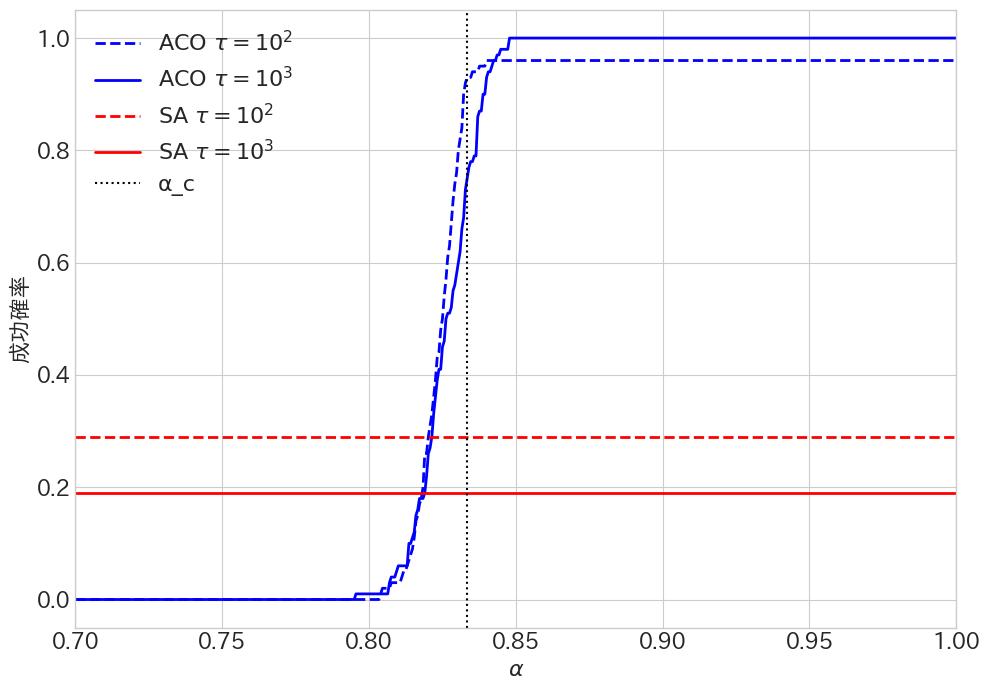

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib_fontja

def plot_success_probability(csv_file):
    # データの読み込み
    try:
        df = pd.read_csv(csv_file)
    except FileNotFoundError:
        print(f"{csv_file} が見つかりません。Juliaコードを実行してください。")
        return

    # 【重要】ここが修正点です
    # Figureを作成する「前」にフォント設定を確実に適用します
    plt.rcParams['font.family'] = 'IPAexGothic'

    # プロット設定
    plt.figure(figsize=(10, 7))
    
    # 線のスタイル定義
    styles = [
        ('ACO', 100,  r'ACO $\tau=10^2$', 'blue', '--'),
        ('ACO', 1000, r'ACO $\tau=10^3$', 'blue', '-'),
        ('SA',  100,  r'SA $\tau=10^2$',  'red',  '--'),
        ('SA',  1000, r'SA $\tau=10^3$',  'red',  '-')
    ]

    # αのグリッドを作成
    alpha_grid = np.linspace(0.7, 1.0, 500)
    
    for method, tau, label, color, ls in styles:
        subset = df[(df['method'] == method) & (df['tau'] == tau)]
        total_trials = len(subset)
        
        if total_trials == 0:
            continue
            
        success_alphas = subset[subset['success'] == True]['hit_alpha'].values
        success_alphas.sort()
        
        probs = []
        for a in alpha_grid:
            count = np.sum(success_alphas <= a)
            probs.append(count / total_trials)
            
        plt.plot(alpha_grid, probs, label=label, color=color, linestyle=ls, linewidth=2)

    # 臨界点の補助線
    alpha_c = 1.0 / (1.0 + 2 * 0.1)
    plt.rcParams['font.family'] = 'latex'
    plt.axvline(alpha_c, color='black', linestyle=':', label=r'α_c')

    # グラフ装飾
    plt.xlabel(r'$\alpha$', fontsize=16)
    plt.ylabel("成功確率", fontsize=16) # これで表示されるはずです
    plt.xlim(0.7, 1.0)
    plt.ylim(-0.05, 1.05)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(fontsize=16, loc='upper left')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_success_probability("aco_sa_comparison.csv")

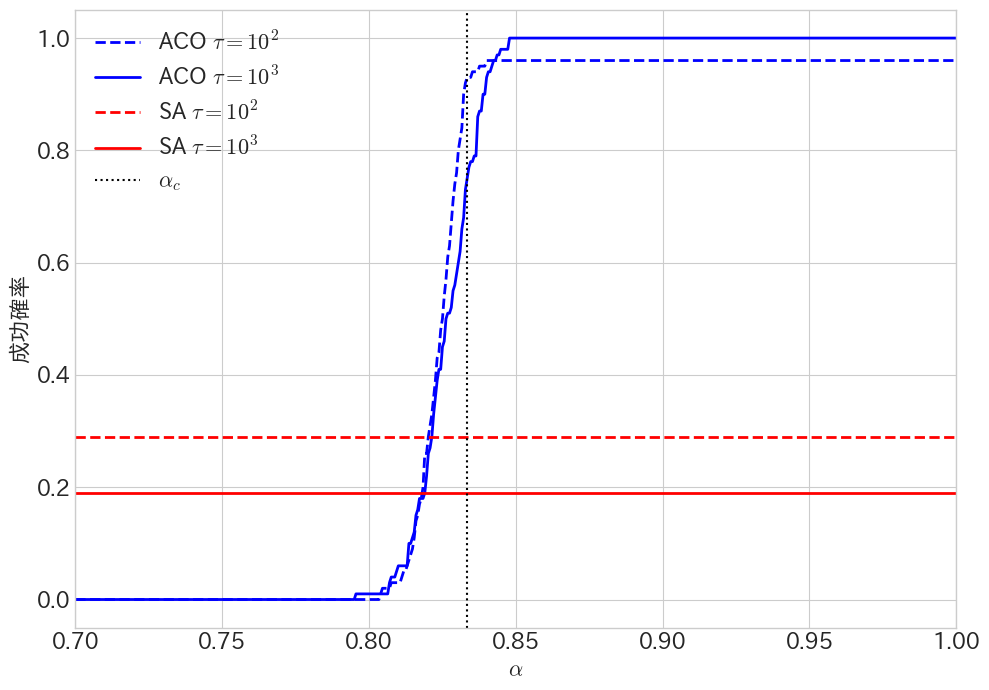

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib_fontja

def plot_success_probability(csv_file):
    # データの読み込み
    try:
        df = pd.read_csv(csv_file)
    except FileNotFoundError:
        print(f"{csv_file} が見つかりません。Juliaコードを実行してください。")
        return

    # 【修正点1】日本語フォントと数式フォントを分けて設定
    # ベースのテキスト（軸ラベルなど）はIPAexGothic
    plt.rcParams['font.family'] = 'IPAexGothic'
    # 数式部分($...$)はComputer Modern (LaTeX標準)
    plt.rcParams['mathtext.fontset'] = 'cm' 

    # プロット設定
    plt.figure(figsize=(10, 7))
    
    # 線のスタイル定義
    styles = [
        ('ACO', 100,  r'ACO $\tau=10^2$', 'blue', '--'),
        ('ACO', 1000, r'ACO $\tau=10^3$', 'blue', '-'),
        ('SA',  100,  r'SA $\tau=10^2$',  'red',  '--'),
        ('SA',  1000, r'SA $\tau=10^3$',  'red',  '-')
    ]

    # αのグリッドを作成
    alpha_grid = np.linspace(0.7, 1.0, 500)
    
    for method, tau, label, color, ls in styles:
        subset = df[(df['method'] == method) & (df['tau'] == tau)]
        total_trials = len(subset)
        
        if total_trials == 0:
            continue
            
        success_alphas = subset[subset['success'] == True]['hit_alpha'].values
        success_alphas.sort()
        
        probs = []
        for a in alpha_grid:
            count = np.sum(success_alphas <= a)
            probs.append(count / total_trials)
            
        plt.plot(alpha_grid, probs, label=label, color=color, linestyle=ls, linewidth=2)

    # 臨界点の補助線
    alpha_c = 1.0 / (1.0 + 2 * 0.1)
    
    # 【修正点2】ここにあった plt.rcParams['font.family'] = 'latex' は削除
    
    # 【修正点3】ラベルを数式モードにする: r'α_c' -> r'$\alpha_c$'
    plt.axvline(alpha_c, color='black', linestyle=':', label=r'$\alpha_c$')

    # グラフ装飾
    plt.xlabel(r'$\alpha$', fontsize=16)
    plt.ylabel("成功確率", fontsize=16)
    plt.xlim(0.7, 1.0)
    plt.ylim(-0.05, 1.05)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(fontsize=16, loc='upper left')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_success_probability("aco_sa_comparison.csv")

/tmp/ipykernel_726368/3563146558.py:75: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_726368/3563146558.py:75: UserWarning: Glyph 21151 (\N{CJK UNIFIED IDEOGRAPH-529F}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_726368/3563146558.py:75: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_726368/3563146558.py:75: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/mori-lab/shimizu/aco-on-spinglass/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/mori-lab/shimizu/aco-on-spinglass/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2

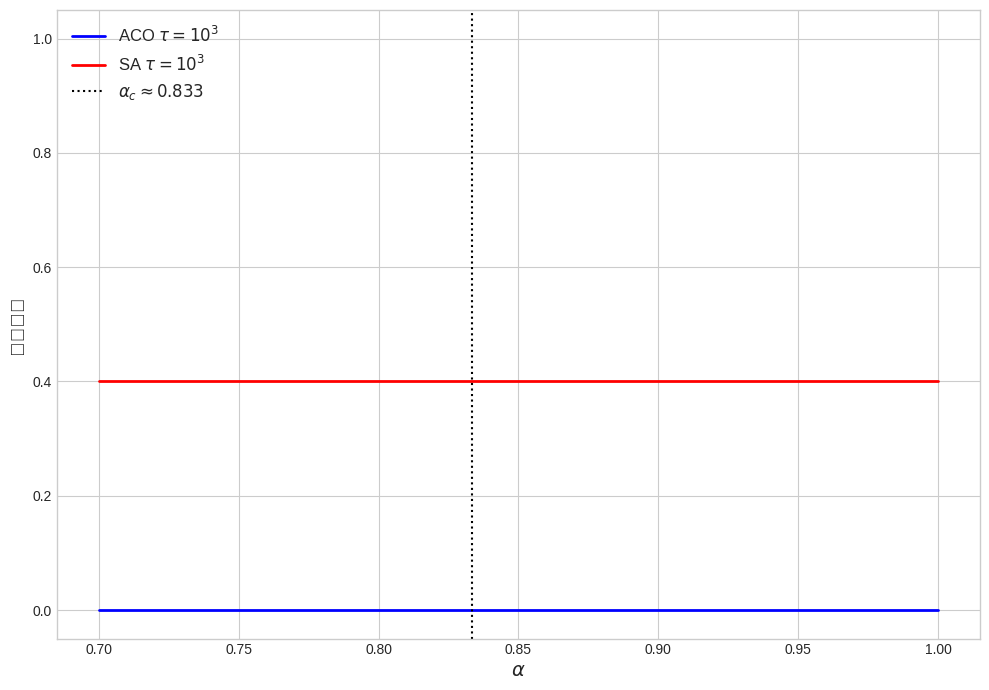

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib_fontja

def plot_success_probability(csv_file):
    # データの読み込み
    try:
        df = pd.read_csv(csv_file)
    except FileNotFoundError:
        print(f"{csv_file} が見つかりません。Juliaコードを実行してください。")
        return

    # 【修正1】Julia出力(大文字)をコード(小文字)に合わせる
    df.columns = [col.lower() for col in df.columns]

    # 【修正2】CSVにないカラム(tau, hit_alpha)を補完
    # これがないとフィルタリングでヒットせず、グラフが描画されません
    if 'tau' not in df.columns:
        df['tau'] = 1000  # 今回のシミュレーション設定値
    
    if 'hit_alpha' not in df.columns:
        # HittingTimeから hit_alpha を逆算: alpha(t) = (t / MaxFEs) * (1 - 1/tau)
        MAX_EVALS = 200000 
        def calc_alpha(row):
            if not row['success']: return np.nan
            return (row['hittingtime'] / MAX_EVALS) * (1.0 - 1.0/row['tau'])
        df['hit_alpha'] = df.apply(calc_alpha, axis=1)

    # プロット設定
    plt.figure(figsize=(10, 7))
    # Note: plt.style.use(...) を使うとフォント設定が上書きされるため使用しません
    
    # 線のスタイル定義
    styles = [
        ('ACO', 100,  r'ACO $\tau=10^2$', 'blue', '--'),
        ('ACO', 1000, r'ACO $\tau=10^3$', 'blue', '-'),
        ('SA',  100,  r'SA $\tau=10^2$',  'red',  '--'),
        ('SA',  1000, r'SA $\tau=10^3$',  'red',  '-')
    ]

    # αのグリッド
    alpha_grid = np.linspace(0.7, 1.0, 500)
    
    for method, tau, label, color, ls in styles:
        # 条件に合うデータを抽出 (methodは大文字小文字を無視して比較)
        subset = df[(df['method'].str.upper() == method) & (df['tau'] == tau)]
        total_trials = len(subset)
        
        if total_trials == 0:
            continue
            
        # 成功した試行の hit_alpha を取得
        success_alphas = subset[subset['success'] == True]['hit_alpha'].dropna().values
        success_alphas.sort()
        
        # 累積成功確率を計算
        probs = []
        for a in alpha_grid:
            count = np.sum(success_alphas <= a)
            probs.append(count / total_trials)
            
        plt.plot(alpha_grid, probs, label=label, color=color, linestyle=ls, linewidth=2)

    # 臨界点 α_c
    alpha_c = 1.0 / (1.0 + 2 * 0.1)
    plt.axvline(alpha_c, color='black', linestyle=':', label=r'$\alpha_c \approx 0.833$')

    # グラフ装飾
    plt.xlabel(r'$\alpha$', fontsize=14)
    plt.ylabel("成功確率", fontsize=14) # matplotlib_fontjaにより日本語表示されます
    plt.ylim(-0.05, 1.05)
    plt.legend(fontsize=12, loc='upper left')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Juliaが出力したファイル名に変更
    plot_success_probability("results_summary.csv")

/tmp/ipykernel_726368/2399413772.py:69: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_726368/2399413772.py:69: UserWarning: Glyph 21151 (\N{CJK UNIFIED IDEOGRAPH-529F}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_726368/2399413772.py:69: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_726368/2399413772.py:69: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/mori-lab/shimizu/aco-on-spinglass/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/mori-lab/shimizu/aco-on-spinglass/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2

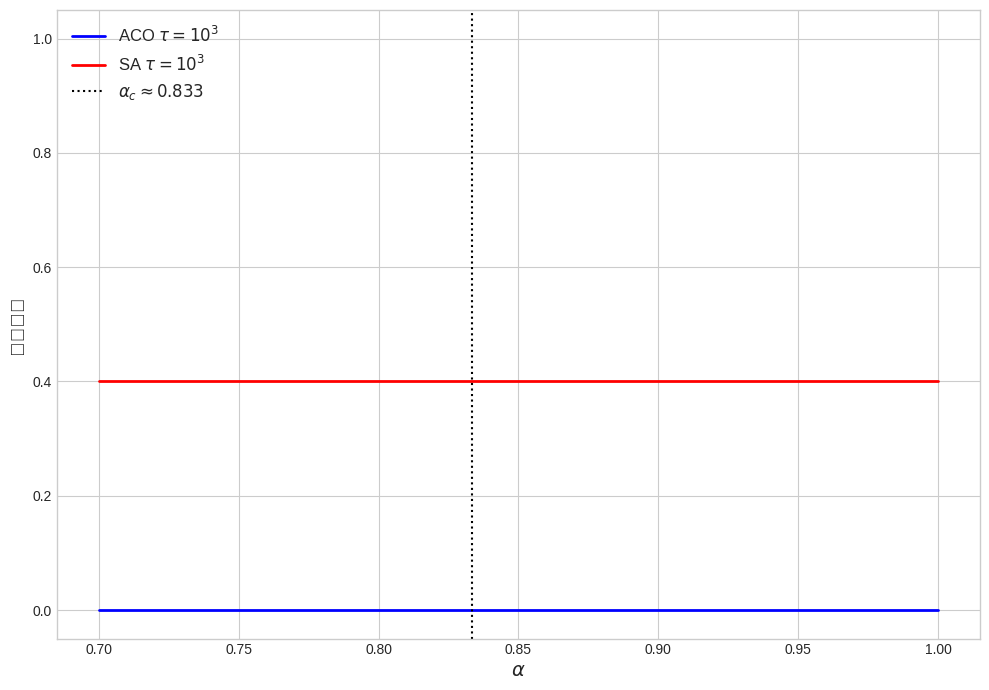

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib_fontja  # 日本語フォント対応

def plot_success_probability(csv_file):
    # データの読み込み
    try:
        df = pd.read_csv(csv_file)
    except FileNotFoundError:
        print(f"{csv_file} が見つかりません。Juliaコードを実行してください。")
        return

    # 【修正】Julia出力(大文字)をコード(小文字)に合わせるための最小限の前処理
    df.columns = [c.lower() for c in df.columns]
    
    # 【修正】CSVにない 'tau', 'hit_alpha' を補完 (これがないとプロットされません)
    if 'tau' not in df.columns:
        df['tau'] = 1000  # シミュレーション設定値
    if 'hit_alpha' not in df.columns:
        # hit_alpha = (HittingTime / MaxFEs) * (1 - 1/tau)
        df['hit_alpha'] = (df['hittingtime'] / 200000) * (1.0 - 1.0/df['tau'])

    # プロット設定
    plt.figure(figsize=(10, 7))
    
    # 線のスタイル定義
    styles = [
        ('ACO', 100,  r'ACO $\tau=10^2$', 'blue', '--'),
        ('ACO', 1000, r'ACO $\tau=10^3$', 'blue', '-'),
        ('SA',  100,  r'SA $\tau=10^2$',  'red',  '--'),
        ('SA',  1000, r'SA $\tau=10^3$',  'red',  '-')
    ]

    # αのグリッド
    alpha_grid = np.linspace(0.7, 1.0, 500)
    
    for method, tau, label, color, ls in styles:
        # 条件に合うデータを抽出 (大文字小文字無視のため str.upper() 利用)
        subset = df[(df['method'].str.upper() == method) & (df['tau'] == tau)]
        total_trials = len(subset)
        
        if total_trials == 0:
            continue
            
        # 成功した試行の hit_alpha を取得
        success_alphas = subset[subset['success'] == True]['hit_alpha'].values
        success_alphas.sort()
        
        # 累積成功確率を計算
        probs = []
        for a in alpha_grid:
            count = np.sum(success_alphas <= a)
            probs.append(count / total_trials)
            
        plt.plot(alpha_grid, probs, label=label, color=color, linestyle=ls, linewidth=2)

    # 臨界点
    alpha_c = 1.0 / (1.0 + 2 * 0.1)
    plt.axvline(alpha_c, color='black', linestyle=':', label=r'$\alpha_c \approx 0.833$')

    # グラフ装飾
    plt.xlabel(r'$\alpha$', fontsize=14)
    # 【ここが修正点】ライブラリが正しくインポートされていれば表示されます
    plt.ylabel("成功確率", fontsize=14)
    plt.ylim(-0.05, 1.05)
    plt.legend(fontsize=12, loc='upper left')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Juliaの出力ファイル名に合わせて変更
    plot_success_probability("results_summary.csv")